# Ordinal Regression for activity data (Oct 2022 data)


In [1]:
import pathlib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import Bio
import Bio.Seq
import Bio.SeqIO

import utils

In [2]:
data_dir = pathlib.Path("../data/scratch/Oct22")
figs_dir = pathlib.Path("../data/misc")

In [3]:
seqs = pd.read_csv("../data/sequences_Oct22.tsv", sep="\t")
seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
0,"G43T,T454C,T594A",20356,3,3,"A15S,F152L,N198K",False,1,1VH,H
1,A679G,18573,1,1,K227E,False,2,1VH,H
2,"C17G,A178G,G257A",17532,3,3,"P6R,S60G,G86D",False,3,1VH,H
3,*0*,11321,0,0,*0*,False,4,1VH,H
4,"C71T,A565G",29019,2,2,"A24V,N189D",False,1,1VH,P
...,...,...,...,...,...,...,...,...,...
1485,"T33C,A263T,A491T,G690A,C699G",187,5,2,"K88I,D164V",False,180,3VRL,N
1486,"T33C,G382T,C699G",185,3,1,G128C,False,181,3VRL,N
1487,"T33C,A200T,A444G,T551C,C699G",180,5,2,"H67L,I184T",False,182,3VRL,N
1488,"T33C,T656C,C699G,C713T",125,4,2,"I219T,T238I",False,184,3VRL,N


In [4]:
seqs_no_dups = seqs.drop_duplicates(["parent", "category", "ss_aa"], keep='first')
seqs_no_dups

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
0,"G43T,T454C,T594A",20356,3,3,"A15S,F152L,N198K",False,1,1VH,H
1,A679G,18573,1,1,K227E,False,2,1VH,H
2,"C17G,A178G,G257A",17532,3,3,"P6R,S60G,G86D",False,3,1VH,H
3,*0*,11321,0,0,*0*,False,4,1VH,H
4,"C71T,A565G",29019,2,2,"A24V,N189D",False,1,1VH,P
...,...,...,...,...,...,...,...,...,...
1485,"T33C,A263T,A491T,G690A,C699G",187,5,2,"K88I,D164V",False,180,3VRL,N
1486,"T33C,G382T,C699G",185,3,1,G128C,False,181,3VRL,N
1487,"T33C,A200T,A444G,T551C,C699G",180,5,2,"H67L,I184T",False,182,3VRL,N
1488,"T33C,T656C,C699G,C713T",125,4,2,"I219T,T238I",False,184,3VRL,N


In [5]:
final_seqs = seqs_no_dups[seqs_no_dups.ss_aa != "*0*" ]
final_seqs

,ss_dna,dna_count,dna_dist,aa_dist,ss_aa,early_stop,seq_rank,parent,category
0,"G43T,T454C,T594A",20356,3,3,"A15S,F152L,N198K",False,1,1VH,H
1,A679G,18573,1,1,K227E,False,2,1VH,H
2,"C17G,A178G,G257A",17532,3,3,"P6R,S60G,G86D",False,3,1VH,H
4,"C71T,A565G",29019,2,2,"A24V,N189D",False,1,1VH,P
6,"A328T,G774T",1200,2,2,"T110S,M258I",False,2,1VH,L
...,...,...,...,...,...,...,...,...,...
1485,"T33C,A263T,A491T,G690A,C699G",187,5,2,"K88I,D164V",False,180,3VRL,N
1486,"T33C,G382T,C699G",185,3,1,G128C,False,181,3VRL,N
1487,"T33C,A200T,A444G,T551C,C699G",180,5,2,"H67L,I184T",False,182,3VRL,N
1488,"T33C,T656C,C699G,C713T",125,4,2,"I219T,T238I",False,184,3VRL,N


## create one-hot encoding of ss_aa

In [6]:
class MutationEncoder:

    def __init__(self):
        self.sorted_positions = None
        self.lookupd = {}
        self.num_categories_pos = None
        self.category_start_pos = None
        self.N_one_hot = 0
        self.features = []
        
    
    def fit(self, mutation_list):
        all_mutations = [msplit for m in mutation_list for msplit in m.split(',')]
        all_mutations_pos = np.array([int(m[1:-1]) for m in all_mutations], dtype="int")
        all_mutations_char = np.array([m[-1] for m in all_mutations])
        all_mutations_wt = np.array([m[0] for m in all_mutations])
        
        self.sorted_positions = np.unique(all_mutations_pos)
        # create a lookup dictionary which has all the positions and the characters
        # at each position
        self.lookupd = {s:sorted(set(all_mutations_char[all_mutations_pos == s].tolist())) 
                        for s in self.sorted_positions}
        
        # count number of categories in each position
        self.num_categories_pos = [len(self.lookupd[s]) for s in self.sorted_positions]

        # total length of one_hot vector
        self.N_one_hot= sum(self.num_categories_pos)

        # cumulative sum of the number of categories
        self.category_start_pos = np.concatenate([[0], np.cumsum(self.num_categories_pos)[:-1]])
        
        # name the features
        self.features = []
        for s in self.sorted_positions:
            assert(len(np.unique(all_mutations_wt[all_mutations_pos == s])) == 1)
            wt = all_mutations_wt[all_mutations_pos == s][0] # should all the same wt char here
            for m in self.lookupd[s]:
                self.features.append(f"{wt}{s}{m}")
        
    def encode(self, prot):
        one_hot_prot = np.zeros(self.N_one_hot, dtype=float)
        if prot and prot != "*0*": 
            for m in prot.split(','):
                _, idx, mut = m[0], int(m[1:-1]), m[-1]
                # find out where this category starts in the one_hot index
                cs = self.category_start_pos[self.sorted_positions == idx]
                one_hot_prot[cs + self.lookupd[idx].index(mut)] = 1.
        return one_hot_prot
    
    
response_map = {"H":3, "P":2, "L":1, "N":0}

In [7]:
mutation_list = ['A15S,F152L,N198K',
 'P6R,K227E',
 'P6R,S60G,G86D']

In [8]:
enc = MutationEncoder()
enc.fit(mutation_list)
enc.features

['P6R', 'A15S', 'S60G', 'G86D', 'F152L', 'N198K', 'K227E']

In [9]:
len(enc.features) == enc.N_one_hot

True

In [10]:
prot = 'P6R,K227E'
np.where(enc.encode(prot))[0]

array([0, 6])

In [11]:
np.where(enc.encode(''))[0]

array([], dtype=int64)

## Ordinal regression

We are using the [mord package](https://github.com/fabianp/mord) to do ordinal regression. The steps in this section are 
1. Create design matrix and response vector
1. Run ordinal regression with a small regularization value.
1. Save coefficients

In [12]:
from sklearn.preprocessing import OneHotEncoder # to create the design matrix
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.model_selection import cross_val_score


import mord
from mord import LogisticAT


import scipy.stats


all_results = []

In [13]:
parent = "1VH"
mutation_list = final_seqs[final_seqs.parent == parent].ss_aa.to_list()
enc = MutationEncoder()
enc.fit(mutation_list)

response_vec = final_seqs[final_seqs.parent == parent].category.map(response_map).to_numpy()
one_hot_vecs_pd = final_seqs[final_seqs.parent == parent].ss_aa.map(enc.encode)

In [14]:
design_matrix = np.array(one_hot_vecs_pd.to_list())
design_matrix.shape

(414, 604)

In [15]:
response_vec.shape

(414,)

In [16]:
y = response_vec
X = design_matrix

In [17]:
np.unique(y, return_counts=True)

(array([0, 1, 2, 3]), array([157, 253,   1,   3]))

In [18]:
# Try out model with alpha = 1.0. This will get overwritten in the gridsearch
model = mord.LogisticAT(alpha=0.1)
#model = LogisticAT(alpha=1.0)

model.fit(X, y)

# The score is negative of mean absolute error between prediction and response vector
print(f"Model Score with alpha={model.alpha} : {model.score(X, y):.2f}")

Model Score with alpha=0.1 : -0.01


<AxesSubplot: ylabel='Count'>

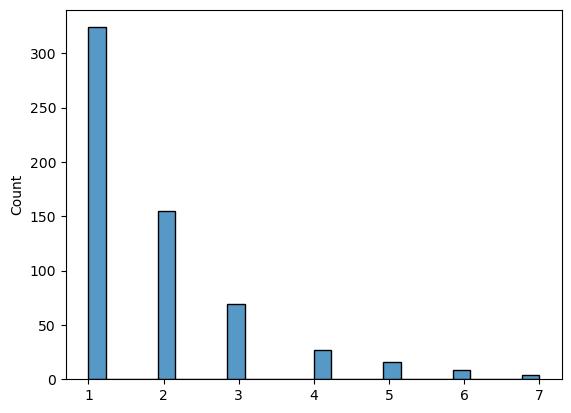

In [19]:
sns.histplot(X.sum(axis=0))

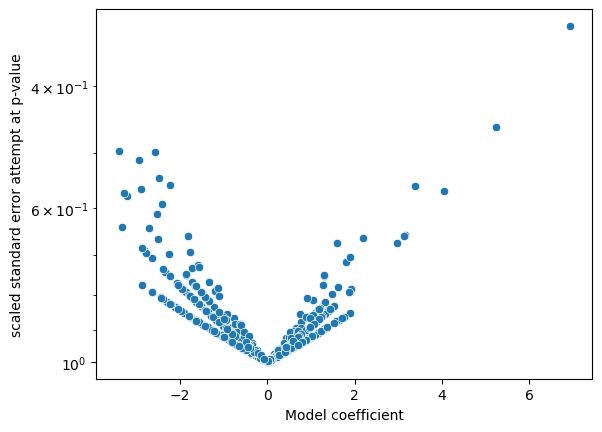

In [20]:
pval = (1 - scipy.stats.norm.cdf(np.abs(model.coef_ * np.sqrt(X.sum(axis=0)) / 10))) * 2
sns.scatterplot(x=model.coef_,y=pval )

ax = plt.gca()
ax.set_yscale('log')
ax.invert_yaxis()

plt.xlabel("Model coefficient")
plt.ylabel("scaled standard error attempt at p-value")
pass

In [21]:
results = pd.DataFrame({'feature':enc.features, 'coef':model.coef_, 
                        'N_obs':X.sum(axis=0).astype(int)})
results["adj_coef"] = results.coef * np.sqrt(results["N_obs"])
results["coef_rank"] = 1
results.loc[np.argsort(results.adj_coef.to_numpy()), "coef_rank"] = np.arange(1, len(results)+1)[::-1]


results["parent"]  = parent
# count the number of observations in each response category for a feature
for category, response in response_map.items():
    results["N_obs_" + category] = \
            X[y == response, :].sum(axis=0).astype(int)
    

all_results.append(results)
results.sort_values(['adj_coef'], ascending=False)


,feature,coef,N_obs,adj_coef,coef_rank,parent,N_obs_H,N_obs_P,N_obs_L,N_obs_N
504,K227E,6.921935,2,9.789095,1,1VH,1,0,1,0
178,G86D,5.246076,2,7.419072,2,1VH,1,0,1,0
449,N198K,3.391377,3,5.874037,3,1VH,1,0,2,0
118,S60G,4.047166,2,5.723557,4,1VH,1,0,1,0
20,A15S,3.151891,2,4.457448,5,1VH,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...
246,F116S,-2.227146,7,-5.892474,600,1VH,0,0,1,6
556,H246R,-2.483054,6,-6.082216,601,1VH,0,0,2,4
530,L237P,-2.933276,5,-6.559004,602,1VH,0,0,1,4
405,L182P,-2.559325,7,-6.771336,603,1VH,0,0,2,5


In [22]:
# # write out to excel

# model_results_excel_filename = f"{output_dir}/{activity_type}_model_results.xlsx"


# with pd.ExcelWriter(model_results_excel_filename, mode='w') as writer:

#     descending_sort_results.to_excel(
#         writer, index=False, sheet_name="feature_scores")
    
#     df_model_scores.sort_values("seq_scores", ascending=False).to_excel(
#         writer, sheet_name='seq_scores', index=False)

In [23]:
parent = "2L"
mutation_list = final_seqs[final_seqs.parent == parent].ss_aa.to_list()
enc = MutationEncoder()
enc.fit(mutation_list)

response_vec = final_seqs[final_seqs.parent == parent].category.map(response_map).to_numpy()
one_hot_vecs_pd = final_seqs[final_seqs.parent == parent].ss_aa.map(enc.encode)

design_matrix = np.array(one_hot_vecs_pd.to_list())
y = response_vec
X = design_matrix

In [24]:
# Try out model with alpha = 1.0. This will get overwritten in the gridsearch
model = mord.LogisticAT(alpha=0.1)
#model = LogisticAT(alpha=1.0)

model.fit(X, y)

# The score is negative of mean absolute error between prediction and response vector
print(f"Model Score with alpha={model.alpha} : {model.score(X, y):.2f}")

Model Score with alpha=0.1 : -0.05


In [25]:
results = pd.DataFrame({'feature':enc.features, 'coef':model.coef_, 
                        'N_obs':X.sum(axis=0).astype(int)})
results["adj_coef"] = results.coef * np.sqrt(results["N_obs"])
results["coef_rank"] = 1
results.loc[np.argsort(results.adj_coef.to_numpy()), "coef_rank"] = np.arange(1, len(results)+1)[::-1]

results["parent"]  = parent
# count the number of observations in each response category for a feature
for category, response in response_map.items():
    results["N_obs_" + category] = \
            X[y == response, :].sum(axis=0).astype(int)
    
all_results.append(results)
results.sort_values(['adj_coef'], ascending=False)

,feature,coef,N_obs,adj_coef,coef_rank,parent,N_obs_H,N_obs_P,N_obs_L,N_obs_N
292,Y131H,5.691596,3,9.858134,1,2L,2,0,1,0
285,H129R,3.922187,5,8.770276,2,2L,2,0,2,1
572,E249G,3.797867,5,8.492290,3,2L,1,0,3,1
380,N167S,2.791533,6,6.837831,4,2L,1,0,4,1
428,N189S,4.806740,2,6.797756,5,2L,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...
168,Q80L,-4.852046,2,-6.861829,615,2L,0,0,0,2
597,L262P,-2.995058,6,-7.336364,616,2L,0,0,2,4
603,H264R,-4.220175,4,-8.440349,617,2L,0,0,0,4
172,Q82R,-6.351521,3,-11.001157,618,2L,0,0,0,3


In [26]:
parent = "3VRL"
mutation_list = final_seqs[final_seqs.parent == parent].ss_aa.to_list()
enc = MutationEncoder()
enc.fit(mutation_list)

response_vec = final_seqs[final_seqs.parent == parent].category.map(response_map).to_numpy()
one_hot_vecs_pd = final_seqs[final_seqs.parent == parent].ss_aa.map(enc.encode)

design_matrix = np.array(one_hot_vecs_pd.to_list())
y = response_vec
X = design_matrix

In [27]:
# Try out model with alpha = 1.0. This will get overwritten in the gridsearch
model = mord.LogisticAT(alpha=0.1)
#model = LogisticAT(alpha=1.0)

model.fit(X, y)

# The score is negative of mean absolute error between prediction and response vector
print(f"Model Score with alpha={model.alpha} : {model.score(X, y):.2f}")

Model Score with alpha=0.1 : -0.08


In [28]:
results = pd.DataFrame({'feature':enc.features, 'coef':model.coef_, 
                        'N_obs':X.sum(axis=0).astype(int)})
results["adj_coef"] = results.coef * np.sqrt(results["N_obs"])
results["coef_rank"] = 1
results.loc[np.argsort(results.adj_coef.to_numpy()), "coef_rank"] = np.arange(1, len(results)+1)[::-1]

results["parent"]  = parent
# count the number of observations in each response category for a feature
for category, response in response_map.items():
    results["N_obs_" + category] = \
            X[y == response, :].sum(axis=0).astype(int)
    
all_results.append(results)
results.sort_values(['adj_coef'], ascending=False)

,feature,coef,N_obs,adj_coef,coef_rank,parent,N_obs_H,N_obs_P,N_obs_L,N_obs_N
544,L261F,5.657090,2,8.000333,1,3VRL,2,0,0,0
97,D49V,4.612212,2,6.522653,2,3VRL,2,0,0,0
4,P6R,3.488368,3,6.042031,3,3VRL,1,0,1,1
93,R48C,4.191864,2,5.928191,4,3VRL,1,1,0,0
215,C101S,3.774707,2,5.338242,5,3VRL,0,2,0,0
...,...,...,...,...,...,...,...,...,...,...
179,G86S,-3.148646,3,-5.453615,557,3VRL,0,0,0,3
168,L81P,-2.778787,4,-5.557573,558,3VRL,0,0,2,2
435,M209V,-3.440874,3,-5.959768,559,3VRL,0,0,1,2
386,I184T,-3.189953,4,-6.379907,560,3VRL,0,0,1,3


### Combine all the results

In [29]:
all_results_pd = pd.concat(all_results)

In [33]:
all_results_pd["c_feature"] = all_results_pd.feature.str.slice(1, None)


# write out to excel

model_results_excel_filename = f"../output/ordinal_Oct22_model_results.xlsx"


with pd.ExcelWriter(model_results_excel_filename, mode='w') as writer:

    all_results_pd.to_excel(
        writer, index=False, sheet_name="feature_scores")
    
    #df_model_scores.sort_values("seq_scores", ascending=False).to_excel(
    #    writer, sheet_name='seq_scores', index=False)

all_results_pd

,feature,coef,N_obs,adj_coef,coef_rank,parent,N_obs_H,N_obs_P,N_obs_L,N_obs_N,c_feature
0,H3Q,0.510237,1,0.510237,205,1VH,0,0,1,0,3Q
1,T4I,-1.110812,1,-1.110812,431,1VH,0,0,0,1,4I
2,P6R,-1.374411,3,-2.380549,535,1VH,1,0,0,2,6R
3,A7V,0.802737,2,1.135242,85,1VH,0,0,2,0,7V
4,Q8L,0.792105,1,0.792105,135,1VH,0,0,1,0,8L
...,...,...,...,...,...,...,...,...,...,...,...
556,D267G,0.121581,3,0.210584,222,3VRL,0,2,0,1,267G
557,D267N,-0.821582,1,-0.821582,331,3VRL,0,0,0,1,267N
558,G268D,-1.761533,2,-2.491183,478,3VRL,0,0,1,1,268D
559,W269R,1.595561,2,2.256464,71,3VRL,0,2,0,0,269R


In [31]:
( 
    all_results_pd
    .groupby('c_feature')
    .filter(lambda x: len(x) >= 3)
    .groupby('c_feature')["coef_rank"]
    .mean().sort_values()
)

c_feature
172R     48.333333
249G     65.666667
92R      84.000000
248V     86.000000
72A      88.666667
           ...    
81P     528.000000
237P    529.333333
88I     535.333333
174S    537.000000
168R    544.000000
Name: coef_rank, Length: 243, dtype: float64

In [32]:
( 
    all_results_pd
#    .groupby('c_feature')
#    .filter(lambda x: len(x) >= 3)
    .groupby('c_feature')["coef_rank"]
    .mean().sort_values()
)

c_feature
131H      1.0
261F      1.0
60G       8.0
226T      8.0
152L      8.0
        ...  
242G    585.5
83C     589.0
222Q    597.0
261L    597.5
67R     600.0
Name: coef_rank, Length: 993, dtype: float64